In [1]:
# let's look at the tensorBoard tool
# https://www.tensorflow.org/tensorboard/get_started
# https://www.tensorflow.org/tensorboard/get_started#tensorboard-usage

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np


In [4]:
(X_train, y_train), (X_test,y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0  

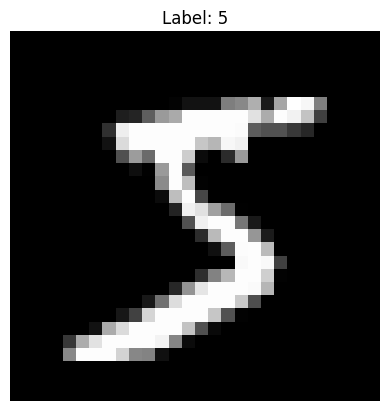

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [15]:
# Fix: Change the output layer activation from "sigmoid" to "softmax" for multi-class classification
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")  # Corrected activation
])

tb_callbacks = keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)
model.compile(optimizer="SGD",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test), callbacks=[tb_callbacks])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8336 - loss: 0.6562 - val_accuracy: 0.9052 - val_loss: 0.3508
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9082 - loss: 0.3306 - val_accuracy: 0.9201 - val_loss: 0.2870
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9213 - loss: 0.2820 - val_accuracy: 0.9292 - val_loss: 0.2555
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9295 - loss: 0.2520 - val_accuracy: 0.9339 - val_loss: 0.2331
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9357 - loss: 0.2296 - val_accuracy: 0.9384 - val_loss: 0.2134


In [16]:
# we can run tensorboard in the terminal with the following command:
# tensorboard --logdir logs/ --port 6006

# within vscode, we can use the "TensorBoard: Start TensorBoard" command from the command palette (Ctrl+Shift+P) and select the "logs/" directory as the log directory. This will start TensorBoard and open it in a new tab within vscode. 
# within jupyter notebook, we can use the following code to start TensorBoard:  
%load_ext tensorboard
%tensorboard --logdir logs/ --port 6006 